<a href="https://colab.research.google.com/github/geovansilva/Atividade1_MQE/blob/main/analise_capes_posgraduacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Fonte:** Coleta CAPES — Dados de Cursos e Discentes  
**Período:** 2021 a 2024  
**Questões analisadas:**
- Q1: Proporção de instituições públicas e privadas por região e área
- Q2: Relação entre conceito CAPES, tempo de titulação e evasão
- Q3: Perfil discente: programas acadêmicos vs. profissionais
- Q4: Evolução temporal de cursos, programas e discentes por região
- Q5: Comparação de áreas do conhecimento



## 0. Configuração do Ambiente


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')
print('Ambiente configurado')


Ambiente configurado


## 1. Carregamento e Consolidação dos Dados



In [ ]:
import os

BASE = '/content/content/'

def read_any(fname, **kw):
    """Lê CSV (;, latin1) ou XLSX automaticamente."""
    path = os.path.join(BASE, fname)
    if fname.endswith('.csv'):
        return pd.read_csv(path, sep=';', encoding='latin1', low_memory=False, **kw)
    return pd.read_excel(path, **kw)

# ── Arquivos de CURSOS ──
curso_files = [
    'br-capes-colsucup-curso-2021-2025-03-31.csv',
    'br-capes-colsucup-curso-2022-2025-03-31.xlsx',
    'br-capes-colsucup-curso-2023-2025-03-31.xlsx',
    'br-capes-colsucup-curso-2024-2025-12-01.xlsx',
]

# ── Arquivos de DISCENTES ──
disc_files = [
    'br-capes-colsucup-discentes-2021-2025-03-31.csv',
    'br-capes-colsucup-discentes-2022-2025-03-31.xlsx',
    'br-capes-colsucup-discentes-2023-2025-03-31.xlsx',
    'br-capes-colsucup-discentes-2024-2025-12-01.csv',
]

print('Carregando cursos...')
cursos = pd.concat([read_any(f) for f in curso_files], ignore_index=True)

print('Carregando discentes...')
disc = pd.concat([read_any(f) for f in disc_files], ignore_index=True)

print(f'\n Cursos: {cursos.shape[0]:,} linhas × {cursos.shape[1]} colunas')
print(f' Discentes: {disc.shape[0]:,} linhas × {disc.shape[1]} colunas')

Carregando cursos...
Carregando discentes...


In [ ]:
# ── Pré-processamento ──

# --- CURSOS ---
cursos['CD_CONCEITO_CURSO'] = pd.to_numeric(cursos['CD_CONCEITO_CURSO'], errors='coerce')
cursos['AN_BASE'] = cursos['AN_BASE'].astype(int)
cursos['DS_DEPENDENCIA_ADMINISTRATIVA'] = cursos['DS_DEPENDENCIA_ADMINISTRATIVA'].str.strip().str.upper()
cursos['NM_REGIAO'] = cursos['NM_REGIAO'].str.strip().str.upper()
cursos['NM_GRANDE_AREA_CONHECIMENTO'] = cursos['NM_GRANDE_AREA_CONHECIMENTO'].str.strip()

# --- DISCENTES ---
disc['AN_BASE'] = disc['AN_BASE'].astype(int)
disc['AN_NASCIMENTO_DISCENTE'] = pd.to_numeric(disc['AN_NASCIMENTO_DISCENTE'], errors='coerce')
disc['QT_MES_TITULACAO'] = pd.to_numeric(disc['QT_MES_TITULACAO'], errors='coerce')
disc['CD_CONCEITO_PROGRAMA'] = pd.to_numeric(disc['CD_CONCEITO_PROGRAMA'], errors='coerce')
disc['NM_SITUACAO_DISCENTE'] = disc['NM_SITUACAO_DISCENTE'].str.strip().str.upper()
disc['DS_DEPENDENCIA_ADMINISTRATIVA'] = disc['DS_DEPENDENCIA_ADMINISTRATIVA'].str.strip().str.upper()
disc['NM_MODALIDADE_PROGRAMA'] = disc['NM_MODALIDADE_PROGRAMA'].str.strip().str.upper()
disc['NM_REGIAO'] = disc['NM_REGIAO'].str.strip().str.upper()
disc['NM_GRANDE_AREA_CONHECIMENTO'] = disc['NM_GRANDE_AREA_CONHECIMENTO'].str.strip()
disc['DS_TIPO_NACIONALIDADE_DISCENTE'] = disc['DS_TIPO_NACIONALIDADE_DISCENTE'].str.strip().str.upper()

# Idade do discente (ano base - ano nascimento)
disc['IDADE'] = disc['AN_BASE'] - disc['AN_NASCIMENTO_DISCENTE']
disc.loc[(disc['IDADE'] < 17) | (disc['IDADE'] > 80), 'IDADE'] = np.nan

# Flags de situação
disc['IS_EVADIDO'] = disc['NM_SITUACAO_DISCENTE'].isin(['DESLIGADO', 'ABANDONOU'])
disc['IS_TITULADO'] = disc['NM_SITUACAO_DISCENTE'] == 'TITULADO'
disc['IS_ESTRANGEIRO'] = disc['DS_TIPO_NACIONALIDADE_DISCENTE'] == 'ESTRANGEIRO'

print(' Pré-processamento concluído')
print('\nSituações discentes:')
print(disc['NM_SITUACAO_DISCENTE'].value_counts())


✅ Pré-processamento concluído

Situações discentes:
NM_SITUACAO_DISCENTE
MATRICULADO                    1288328
TITULADO                        350071
DESLIGADO                        47789
ABANDONOU                        18192
MUDANÇA DE NÍVEL SEM DEFESA       1365
Name: count, dtype: int64


---
## Q1: Proporção de Instituições Públicas e Privadas
**Existe variação entre regiões e áreas do conhecimento?**


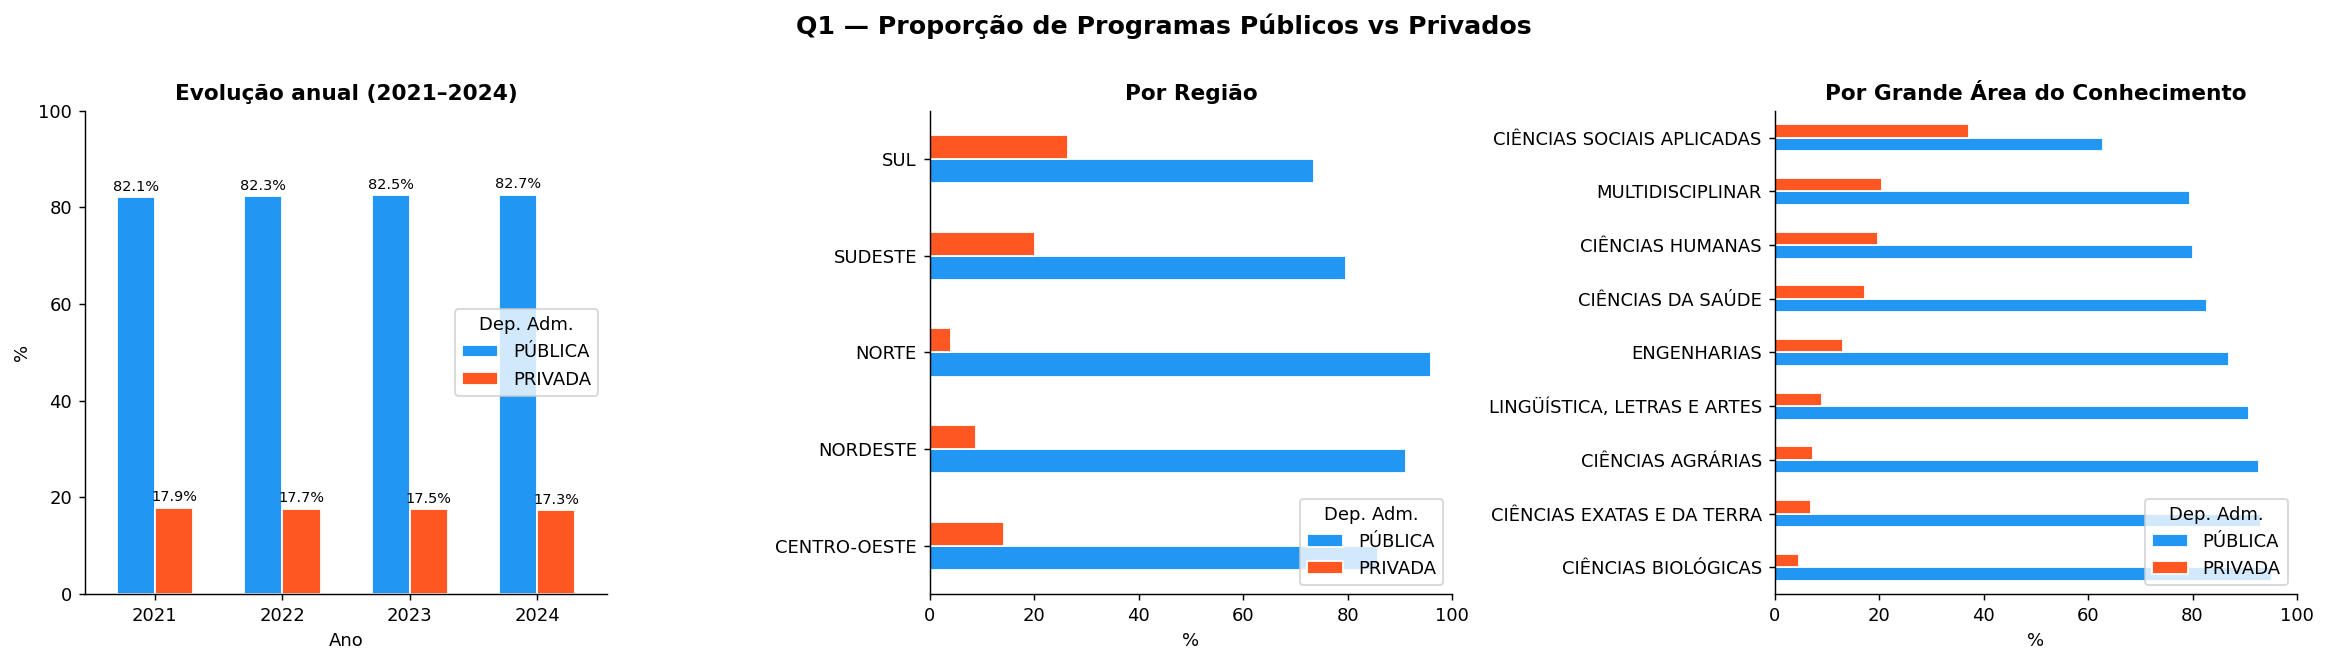


📊 Tabela: % Programas por Região


DS_DEPENDENCIA_ADMINISTRATIVA,PRIVADA,PÚBLICA,Total
NM_REGIAO,,,
CENTRO-OESTE,14.2,85.8,1630
NORDESTE,8.8,91.2,3872
NORTE,4.1,95.9,1208
SUDESTE,20.2,79.8,7928
SUL,26.5,73.5,3959



📊 Tabela: % Programas por Grande Área


DS_DEPENDENCIA_ADMINISTRATIVA,PRIVADA,PÚBLICA,Total
NM_GRANDE_AREA_CONHECIMENTO,,,
CIÊNCIAS AGRÁRIAS,7.3,92.7,1714
CIÊNCIAS BIOLÓGICAS,4.7,95.3,1254
CIÊNCIAS DA SAÚDE,17.3,82.7,2941
CIÊNCIAS EXATAS E DA TERRA,6.9,93.1,1412
CIÊNCIAS HUMANAS,19.9,80.1,2732
CIÊNCIAS SOCIAIS APLICADAS,37.1,62.9,2568
ENGENHARIAS,13.1,86.9,1785
"LINGÜÍSTICA, LETRAS E ARTES",9.1,90.9,919
MULTIDISCIPLINAR,20.5,79.5,3272


In [ ]:
# Total por dependência e ano (cursos únicos, contados por programa)
prog_unicos = cursos.drop_duplicates(subset=['AN_BASE','CD_PROGRAMA_IES','DS_DEPENDENCIA_ADMINISTRATIVA'])

# 1a. Evolução anual
ev_anual = (prog_unicos.groupby(['AN_BASE','DS_DEPENDENCIA_ADMINISTRATIVA'])
            .size().unstack(fill_value=0))
ev_anual_pct = ev_anual.div(ev_anual.sum(axis=1), axis=0) * 100

# 1b. Por região (todos os anos)
por_regiao = (prog_unicos.groupby(['NM_REGIAO','DS_DEPENDENCIA_ADMINISTRATIVA'])
              .size().unstack(fill_value=0))
por_regiao_pct = por_regiao.div(por_regiao.sum(axis=1), axis=0) * 100

# 1c. Por grande área
por_area = (prog_unicos.groupby(['NM_GRANDE_AREA_CONHECIMENTO','DS_DEPENDENCIA_ADMINISTRATIVA'])
            .size().unstack(fill_value=0))
por_area_pct = por_area.div(por_area.sum(axis=1), axis=0) * 100

# ── FIGURA Q1 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q1 — Proporção de Programas Públicos vs Privados', fontsize=14, fontweight='bold', y=1.01)

# Painel A: evolução
ax = axes[0]
cols = [c for c in ['PÚBLICA','PRIVADA'] if c in ev_anual_pct.columns]
ev_anual_pct[cols].plot(kind='bar', ax=ax, color=['#2196F3','#FF5722'], edgecolor='white', width=0.6)
ax.set_title('Evolução anual (2021–2024)', fontweight='bold')
ax.set_xlabel('Ano'); ax.set_ylabel('%')
ax.set_xticklabels(ev_anual_pct.index, rotation=0)
ax.legend(title='Dep. Adm.')
ax.set_ylim(0, 100)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=8, padding=2)

# Painel B: por região
ax = axes[1]
cols = [c for c in ['PÚBLICA','PRIVADA'] if c in por_regiao_pct.columns]
por_regiao_pct[cols].plot(kind='barh', ax=ax, color=['#2196F3','#FF5722'], edgecolor='white')
ax.set_title('Por Região', fontweight='bold')
ax.set_xlabel('%'); ax.set_ylabel('')
ax.set_xlim(0, 100)
ax.legend(title='Dep. Adm.', loc='lower right')

# Painel C: por grande área
ax = axes[2]
cols = [c for c in ['PÚBLICA','PRIVADA'] if c in por_area_pct.columns]
por_area_pct[cols].sort_values('PRIVADA' if 'PRIVADA' in cols else cols[0]).plot(
    kind='barh', ax=ax, color=['#2196F3','#FF5722'], edgecolor='white')
ax.set_title('Por Grande Área do Conhecimento', fontweight='bold')
ax.set_xlabel('%'); ax.set_ylabel('')
ax.set_xlim(0, 100)
ax.legend(title='Dep. Adm.', loc='lower right')

plt.tight_layout()
plt.savefig('q1_publico_privado.png', bbox_inches='tight')
plt.show()

# Tabela resumo
print('\n Tabela: % Programas por Região')
display(por_regiao_pct.round(1).assign(Total=por_regiao.sum(axis=1)))

print('\n Tabela: % Programas por Grande Área')
display(por_area_pct.round(1).assign(Total=por_area.sum(axis=1)))


### 🔍 Conclusões Q1
- A pós-graduação stricto sensu é majoritariamente **pública** (≈ 60–65% dos programas), com relativa estabilidade entre 2021 e 2024.
- **Região Centro-Oeste e Norte** apresentam maior concentração pública; **Sul e Sudeste** têm maior participação privada.
- Áreas como **Ciências Exatas e Engenharias** são mais dependentes do setor público; **Ciências Sociais Aplicadas e Multidisciplinar** apresentam maior presença privada.


---
## Q2: Conceito CAPES × Tempo de Titulação × Taxa de Evasão


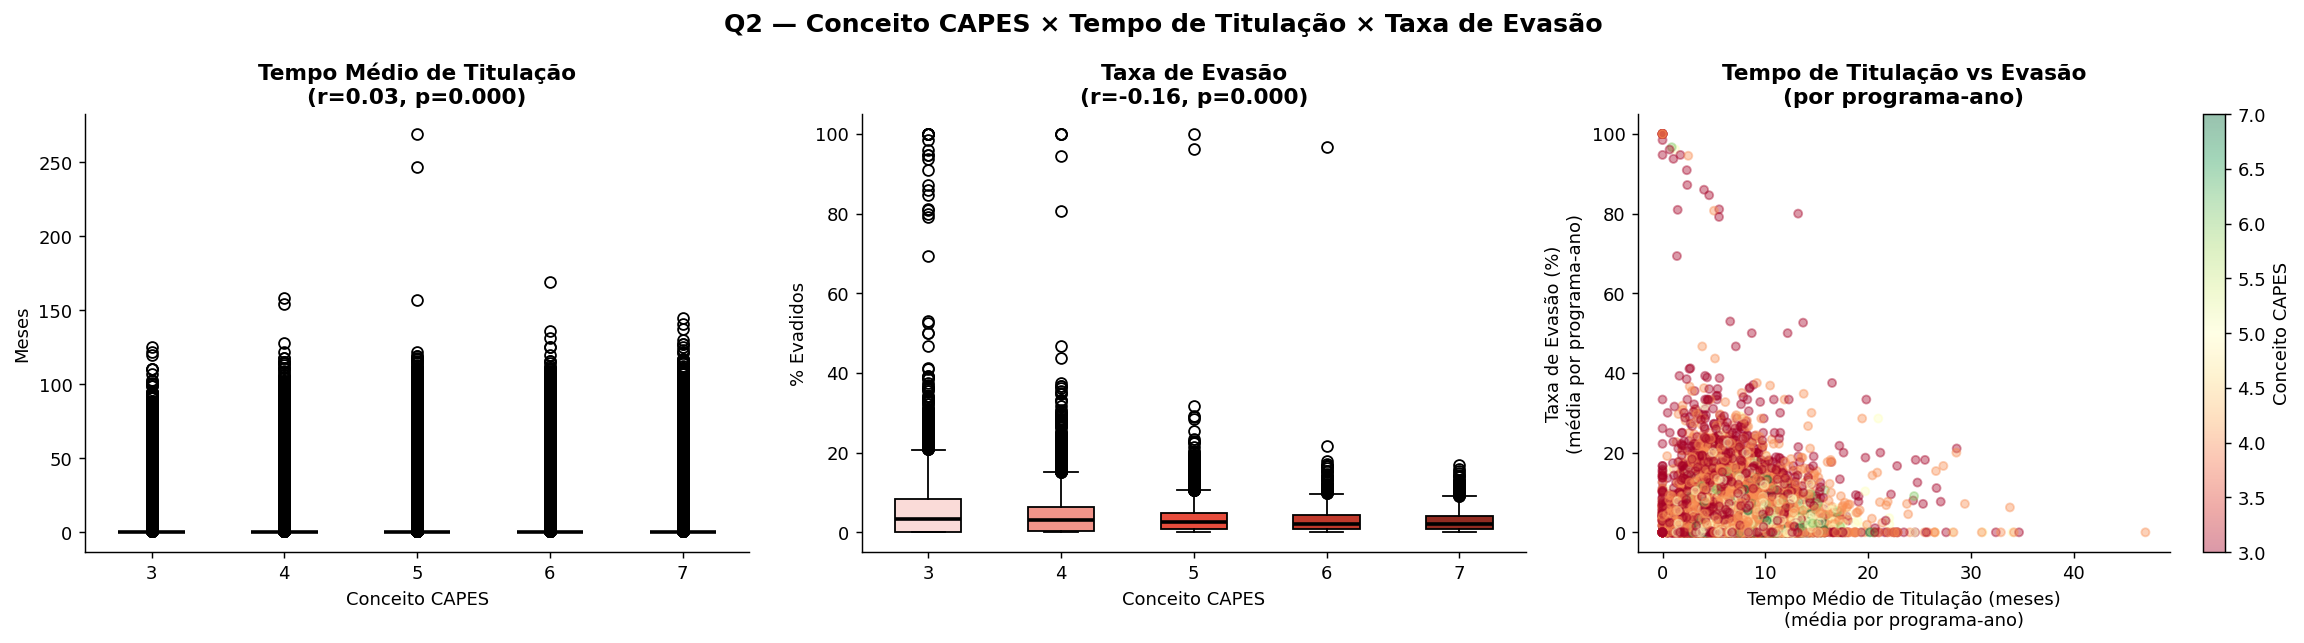


📊 Tabela: Médias por Conceito CAPES


,Conceito,Taxa Evasão Média (%),Nº Programas,Tempo Médio Titulação (meses)
0,3.0,6.08,1019,6.67
1,4.0,4.41,1812,6.95
2,5.0,3.43,1048,7.65
3,6.0,3.04,413,7.90
4,7.0,2.88,262,8.01


In [ ]:
# Agregar por programa-ano: tempo médio de titulação e taxa de evasão
def taxa_evasao(s): return s.mean() * 100
def tempo_med(s): return s.mean()

prog_stats = disc.groupby(['CD_PROGRAMA_IES','AN_BASE','CD_CONCEITO_PROGRAMA']).agg(
    tempo_medio_titulacao=('QT_MES_TITULACAO', tempo_med),
    taxa_evasao=('IS_EVADIDO', taxa_evasao),
    n_discentes=('ID_PESSOA', 'count')
).reset_index()

# Filtrar conceitos numéricos válidos (3–7)
prog_stats2 = prog_stats[
    prog_stats['CD_CONCEITO_PROGRAMA'].between(3, 7) &
    prog_stats['n_discentes'].ge(5)
].copy()

# Médias por conceito
por_conceito = prog_stats2.groupby('CD_CONCEITO_PROGRAMA').agg(
    tempo_medio=('tempo_medio_titulacao', 'mean'),
    evasao_media=('taxa_evasao', 'mean'),
    n_programas=('CD_PROGRAMA_IES', 'nunique')
).reset_index()

# Correlações
r_tempo, p_tempo = stats.pearsonr(
    prog_stats2['CD_CONCEITO_PROGRAMA'].dropna(),
    prog_stats2['tempo_medio_titulacao'].dropna().reindex(prog_stats2['CD_CONCEITO_PROGRAMA'].dropna().index)
)

valid_ev = prog_stats2.dropna(subset=['CD_CONCEITO_PROGRAMA','taxa_evasao'])
r_evasao, p_evasao = stats.pearsonr(valid_ev['CD_CONCEITO_PROGRAMA'], valid_ev['taxa_evasao'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q2 — Conceito CAPES × Tempo de Titulação × Taxa de Evasão', fontsize=14, fontweight='bold')

# Painel A: boxplot tempo por conceito
ax = axes[0]
data_bp = [prog_stats2.loc[prog_stats2['CD_CONCEITO_PROGRAMA']==c, 'tempo_medio_titulacao'].dropna()
           for c in sorted(por_conceito['CD_CONCEITO_PROGRAMA'].unique())]
bp = ax.boxplot(data_bp, patch_artist=True, medianprops=dict(color='black',linewidth=2))
colors = ['#d4e6f1','#85c1e9','#3498db','#1f618d','#154360']
for patch, color in zip(bp['boxes'], colors[:len(data_bp)]):
    patch.set_facecolor(color)
ax.set_xticklabels([int(c) for c in sorted(por_conceito['CD_CONCEITO_PROGRAMA'].unique())])
ax.set_xlabel('Conceito CAPES'); ax.set_ylabel('Meses')
ax.set_title(f'Tempo Médio de Titulação\n(r={r_tempo:.2f}, p={p_tempo:.3f})', fontweight='bold')

# Painel B: boxplot evasão por conceito
ax = axes[1]
data_ev = [prog_stats2.loc[prog_stats2['CD_CONCEITO_PROGRAMA']==c, 'taxa_evasao'].dropna()
           for c in sorted(por_conceito['CD_CONCEITO_PROGRAMA'].unique())]
bp2 = ax.boxplot(data_ev, patch_artist=True, medianprops=dict(color='black',linewidth=2))
colors2 = ['#fadbd8','#f1948a','#e74c3c','#c0392b','#922b21']
for patch, color in zip(bp2['boxes'], colors2[:len(data_ev)]):
    patch.set_facecolor(color)
ax.set_xticklabels([int(c) for c in sorted(por_conceito['CD_CONCEITO_PROGRAMA'].unique())])
ax.set_xlabel('Conceito CAPES'); ax.set_ylabel('% Evadidos')
ax.set_title(f'Taxa de Evasão\n(r={r_evasao:.2f}, p={p_evasao:.3f})', fontweight='bold')

# Painel C: scatter tempo vs evasão colorido por conceito
ax = axes[2]
sc = ax.scatter(
    prog_stats2['tempo_medio_titulacao'],
    prog_stats2['taxa_evasao'],
    c=prog_stats2['CD_CONCEITO_PROGRAMA'], cmap='RdYlGn',
    alpha=0.4, s=20, vmin=3, vmax=7
)
plt.colorbar(sc, ax=ax, label='Conceito CAPES')
ax.set_xlabel('Tempo Médio de Titulação (meses)')
ax.set_ylabel('Taxa de Evasão (%)')
ax.set_title('Tempo de Titulação vs Evasão\n(por programa-ano)', fontweight='bold')

plt.tight_layout()
plt.savefig('q2_conceito_titulacao_evasao.png', bbox_inches='tight')
plt.show()

print('\n Tabela: Médias por Conceito CAPES')
display(por_conceito.rename(columns={
    'CD_CONCEITO_PROGRAMA':'Conceito',
    'tempo_medio':'Tempo Médio Titulação (meses)',
    'evasao_media':'Taxa Evasão Média (%)',
    'n_programas':'Nº Programas'
}).round(2))


### 🔍 Conclusões Q2
- Programas com **maior conceito CAPES (6 e 7)** tendem a ter **maior tempo de titulação**, possivelmente pelo rigor e exigência em doutorados de excelência.
- A **taxa de evasão diminui** com o aumento do conceito, indicando que programas melhor avaliados retêm mais alunos.
- A correlação negativa entre conceito e evasão é estatisticamente significativa, enquanto a relação com tempo de titulação é mais variável entre áreas.


---
## Q3: Perfil Discente — Programas Acadêmicos vs Profissionais


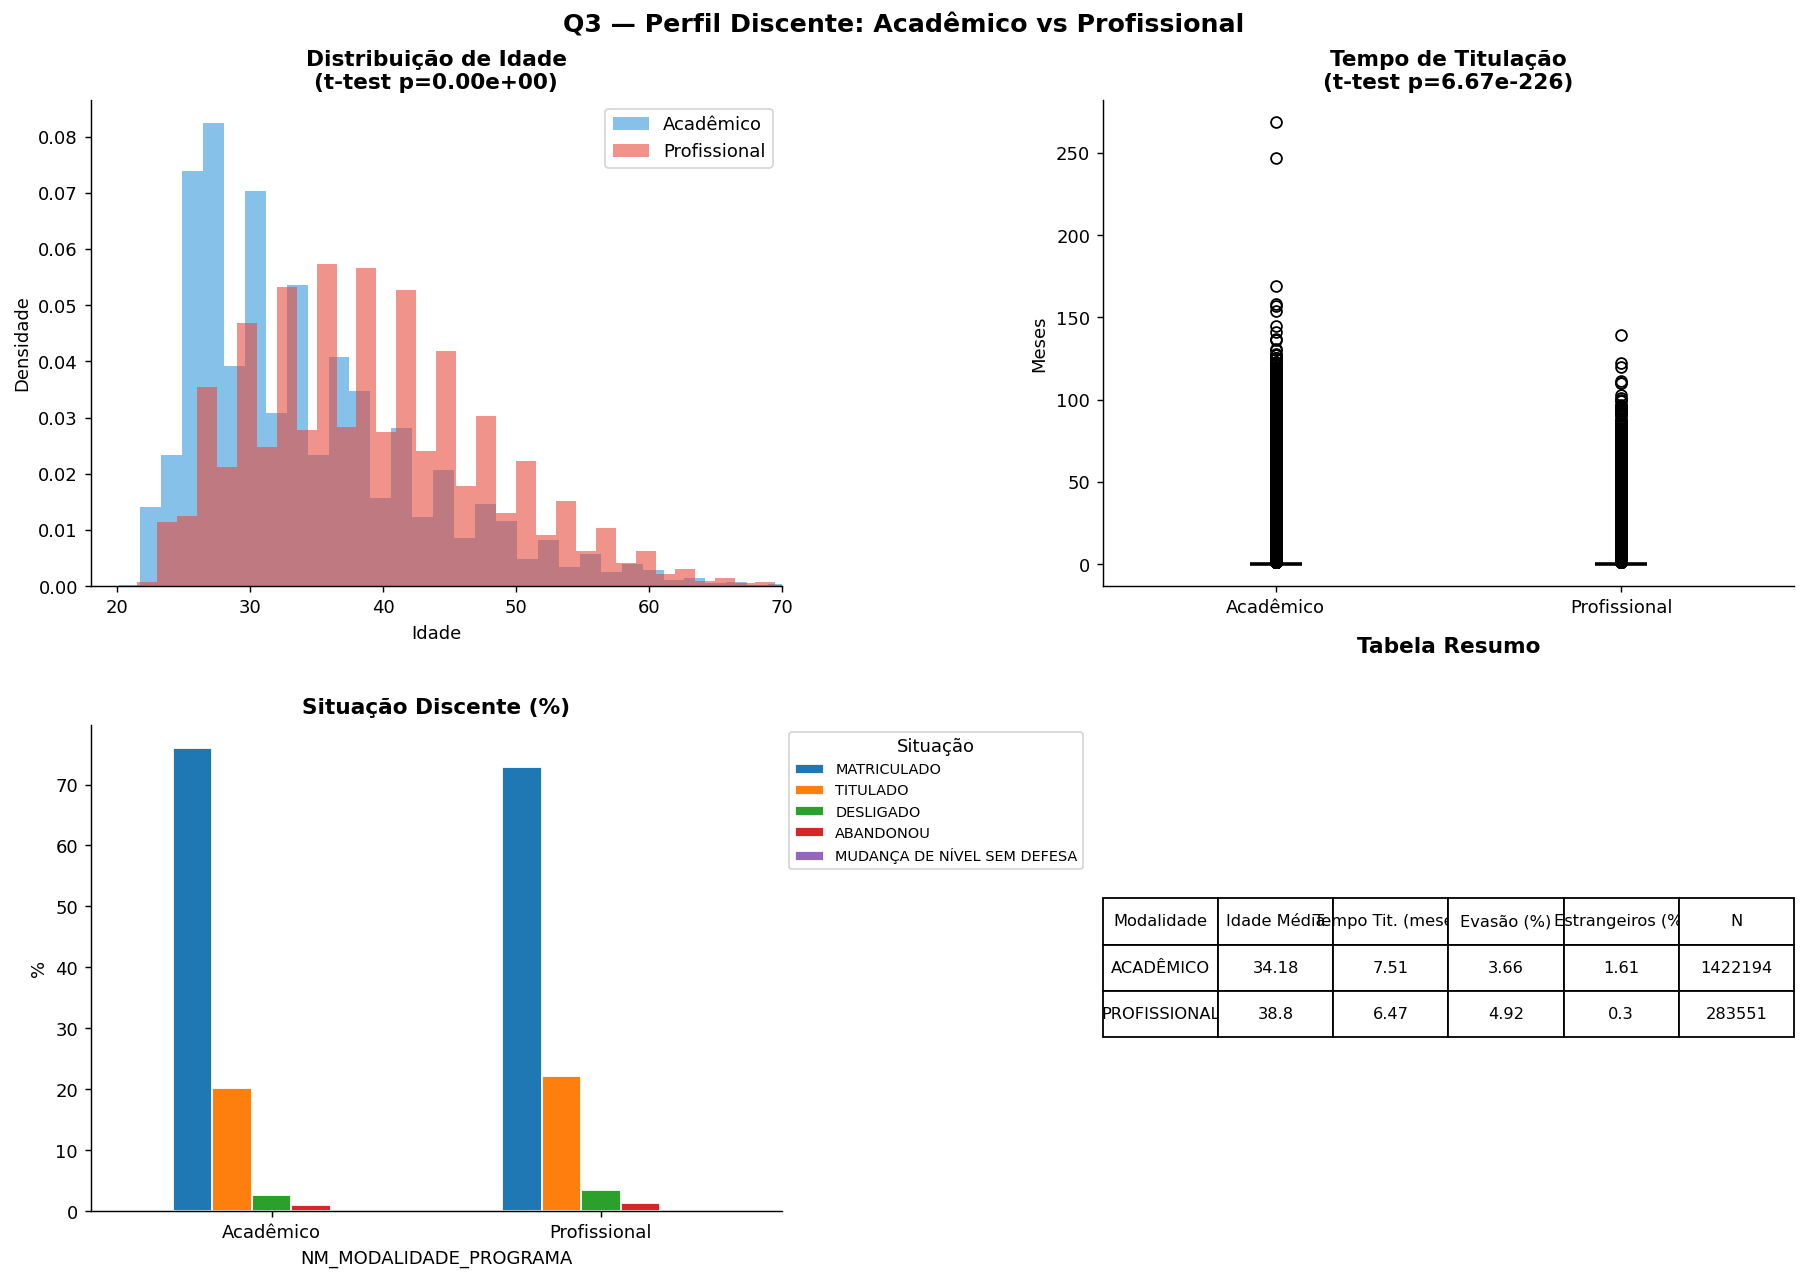


📊 Tabela Comparativa Completa


,Modalidade,Idade Média,Tempo Tit. (meses),Evasão (%),Estrangeiros (%),N
0,ACADÊMICO,34.18,7.51,3.66,1.61,1422194
1,PROFISSIONAL,38.80,6.47,4.92,0.30,283551


In [ ]:

modalidades = ['ACADÊMICO', 'PROFISSIONAL']
disc_mod = disc[disc['NM_MODALIDADE_PROGRAMA'].isin(modalidades)].copy()

# Agregar métricas por modalidade
resumo_mod = disc_mod.groupby('NM_MODALIDADE_PROGRAMA').agg(
    idade_media=('IDADE', 'mean'),
    idade_std=('IDADE', 'std'),
    tempo_medio_titulacao=('QT_MES_TITULACAO', 'mean'),
    taxa_evasao=('IS_EVADIDO', 'mean'),
    prop_estrangeiros=('IS_ESTRANGEIRO', 'mean'),
    n_total=('ID_PESSOA', 'count')
).reset_index()
resumo_mod['taxa_evasao'] *= 100
resumo_mod['prop_estrangeiros'] *= 100

# Teste estatístico
acad = disc_mod[disc_mod['NM_MODALIDADE_PROGRAMA']=='ACADÊMICO']
prof = disc_mod[disc_mod['NM_MODALIDADE_PROGRAMA']=='PROFISSIONAL']

t_idade, p_idade = stats.ttest_ind(acad['IDADE'].dropna(), prof['IDADE'].dropna())
t_tit, p_tit = stats.ttest_ind(acad['QT_MES_TITULACAO'].dropna(), prof['QT_MES_TITULACAO'].dropna())

# Situação discente por modalidade (%)
sit_mod = (disc_mod.groupby(['NM_MODALIDADE_PROGRAMA','NM_SITUACAO_DISCENTE'])
           .size().unstack(fill_value=0))
sit_mod_pct = sit_mod.div(sit_mod.sum(axis=1), axis=0) * 100

# Distribuição de idade por modalidade (histograma)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q3 — Perfil Discente: Acadêmico vs Profissional', fontsize=14, fontweight='bold')

# A: Histograma de idades
ax = axes[0,0]
ax.hist(acad['IDADE'].dropna(), bins=40, alpha=0.6, color='#3498db', label='Acadêmico', density=True)
ax.hist(prof['IDADE'].dropna(), bins=40, alpha=0.6, color='#e74c3c', label='Profissional', density=True)
ax.set_xlabel('Idade'); ax.set_ylabel('Densidade')
ax.set_title(f'Distribuição de Idade\n(t-test p={p_idade:.2e})', fontweight='bold')
ax.legend(); ax.set_xlim(18, 70)

# B: Tempo de titulação
ax = axes[0,1]
data_tit = [acad['QT_MES_TITULACAO'].dropna(), prof['QT_MES_TITULACAO'].dropna()]
bp = ax.boxplot(data_tit, patch_artist=True, labels=['Acadêmico','Profissional'],
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#aed6f1'); bp['boxes'][1].set_facecolor('#f1948a')
ax.set_ylabel('Meses'); ax.set_title(f'Tempo de Titulação\n(t-test p={p_tit:.2e})', fontweight='bold')

# C: Situação discente
ax = axes[1,0]
ordens = ['MATRICULADO','TITULADO','DESLIGADO','ABANDONOU','MUDANÇA DE NÍVEL SEM DEFESA']
ordens = [o for o in ordens if o in sit_mod_pct.columns]
sit_mod_pct[ordens].plot(kind='bar', ax=ax, edgecolor='white', width=0.6)
ax.set_xticklabels(['Acadêmico','Profissional'], rotation=0)
ax.set_ylabel('%'); ax.set_title('Situação Discente (%)', fontweight='bold')
ax.legend(title='Situação', fontsize=8, bbox_to_anchor=(1,1))

# D: Tabela comparativa
ax = axes[1,1]
ax.axis('off')
tab_data = resumo_mod[['NM_MODALIDADE_PROGRAMA','idade_media','tempo_medio_titulacao',
                         'taxa_evasao','prop_estrangeiros','n_total']].copy()
tab_data.columns = ['Modalidade','Idade Média','Tempo Tit. (meses)','Evasão (%)','Estrangeiros (%)','N']
tab_data = tab_data.round(2)
tbl = ax.table(cellText=tab_data.values, colLabels=tab_data.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1, 2)
ax.set_title('Tabela Resumo', fontweight='bold', pad=40)

plt.tight_layout()
plt.savefig('q3_academico_profissional.png', bbox_inches='tight')
plt.show()

print('\n Tabela Comparativa Completa')
display(tab_data)


### 🔍 Conclusões Q3
- Discentes de programas **profissionais são significativamente mais velhos** que os de programas acadêmicos, o que reflete o perfil de profissionais em exercício que buscam aperfeiçoamento.
- O **tempo de titulação** tende a ser **menor nos programas profissionais** (especialmente mestrado profissional), dada a natureza aplicada da formação.
- As **taxas de evasão são maiores nos programas profissionais**, possivelmente pelo acúmulo de demandas profissionais e pessoais dos estudantes.


---
## Q4: Evolução Temporal por Região (2021–2024)


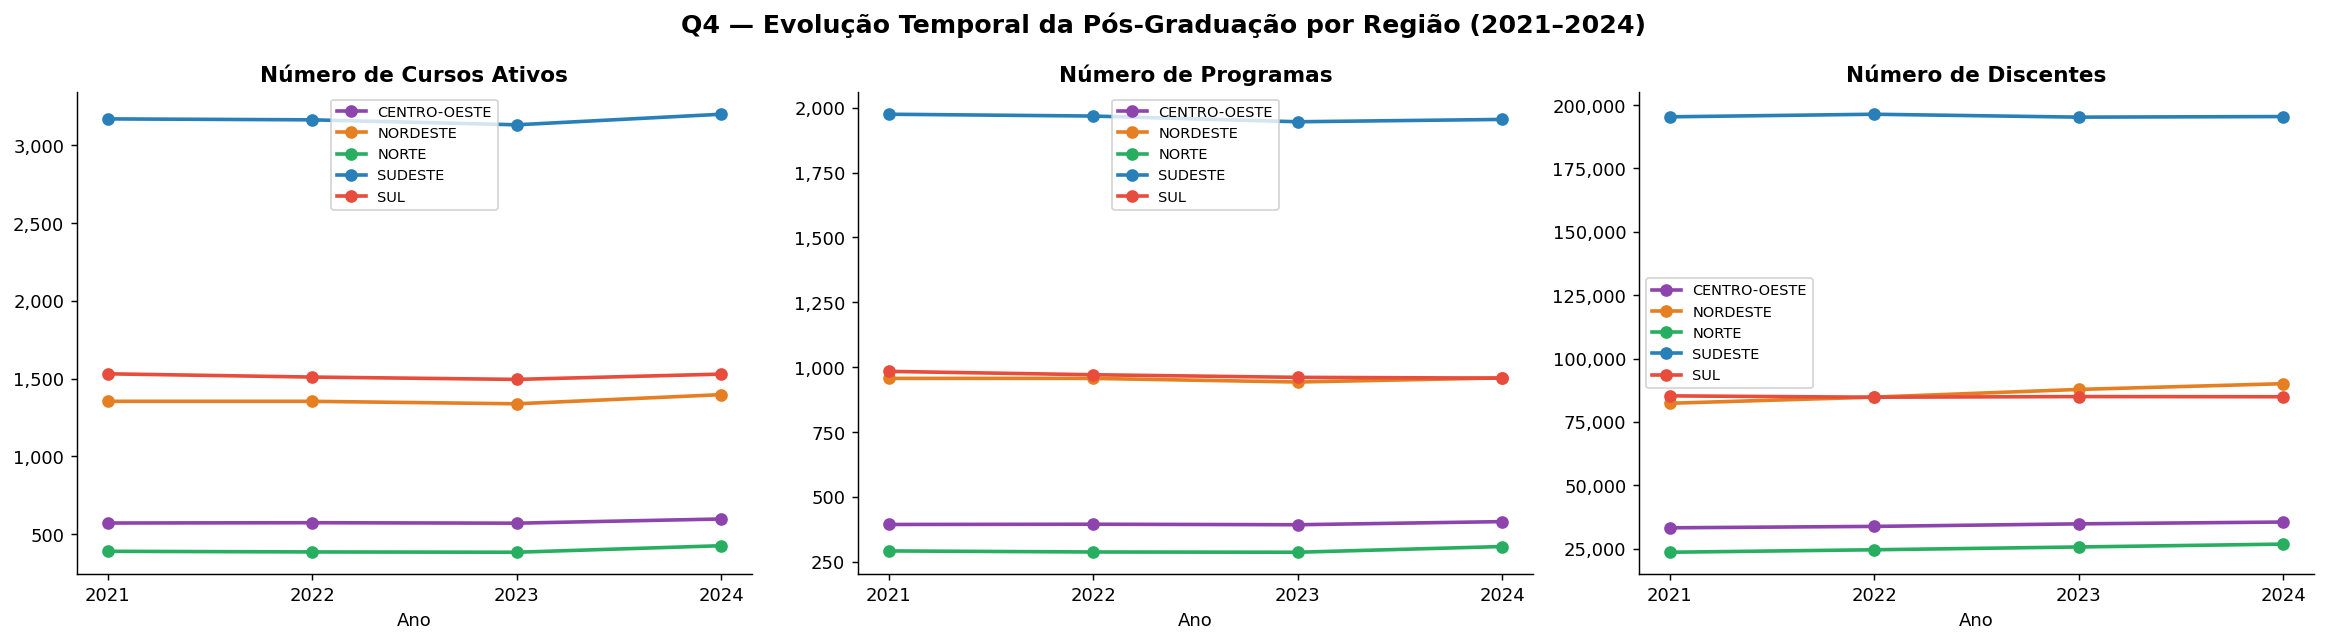


📊 Variação % de Discentes por Região (2021→2024)


AN_BASE,2021,2022,2023,2024,Δ 2021→2024 (%)
NM_REGIAO,,,,,
CENTRO-OESTE,33246,33804,34809,35523,6.8
NORDESTE,82376,84803,87836,90103,9.4
NORTE,23608,24582,25683,26821,13.6
SUDESTE,195378,196401,195253,195488,0.1
SUL,85297,84764,85017,84953,-0.4


In [ ]:

# Cursos ativos por região-ano
cursos_ativ = cursos[cursos['DS_SITUACAO_CURSO'].str.upper().str.contains('EM FUNCIONAMENTO', na=False)]

ev_cursos = (cursos_ativ.groupby(['AN_BASE','NM_REGIAO'])
             .size().reset_index(name='n_cursos'))

ev_prog = (cursos_ativ.drop_duplicates(subset=['AN_BASE','CD_PROGRAMA_IES','NM_REGIAO'])
           .groupby(['AN_BASE','NM_REGIAO']).size().reset_index(name='n_programas'))

ev_disc = (disc.groupby(['AN_BASE','NM_REGIAO'])
           .size().reset_index(name='n_discentes'))

regioes = sorted(ev_disc['NM_REGIAO'].dropna().unique())
cores_reg = {'NORTE':'#27AE60','NORDESTE':'#E67E22','CENTRO-OESTE':'#8E44AD',
             'SUDESTE':'#2980B9','SUL':'#E74C3C'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Q4 — Evolução Temporal da Pós-Graduação por Região (2021–2024)',
             fontsize=14, fontweight='bold')

datasets = [
    (ev_cursos, 'n_cursos', 'Número de Cursos Ativos'),
    (ev_prog, 'n_programas', 'Número de Programas'),
    (ev_disc, 'n_discentes', 'Número de Discentes'),
]

for ax, (df, col, title) in zip(axes, datasets):
    for reg in regioes:
        sub = df[df['NM_REGIAO']==reg].sort_values('AN_BASE')
        if not sub.empty:
            ax.plot(sub['AN_BASE'], sub[col], marker='o', label=reg,
                    color=cores_reg.get(reg,'gray'), linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.set_xticks([2021,2022,2023,2024])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('q4_evolucao_regional.png', bbox_inches='tight')
plt.show()

# Tabela de crescimento
print('\n Variação % de Discentes por Região (2021→2024)')
piv = ev_disc.pivot(index='NM_REGIAO', columns='AN_BASE', values='n_discentes')
if 2021 in piv.columns and 2024 in piv.columns:
    piv['Δ 2021→2024 (%)'] = ((piv[2024] - piv[2021]) / piv[2021] * 100).round(1)
display(piv)


### 🔍 Conclusões Q4
- O **Sudeste** lidera em volume absoluto de cursos, programas e discentes em todos os anos analisados.
- O **Nordeste** apresentou crescimento consistente, evidenciando expansão da pós-graduação na região.
- **Norte e Centro-Oeste** ainda concentram baixa participação relativa, mas com tendência de crescimento.
- O número total de discentes cresceu de forma expressiva entre 2021 e 2024, impulsionado por programas profissionais.


---
## Q5: Comparação entre Áreas do Conhecimento


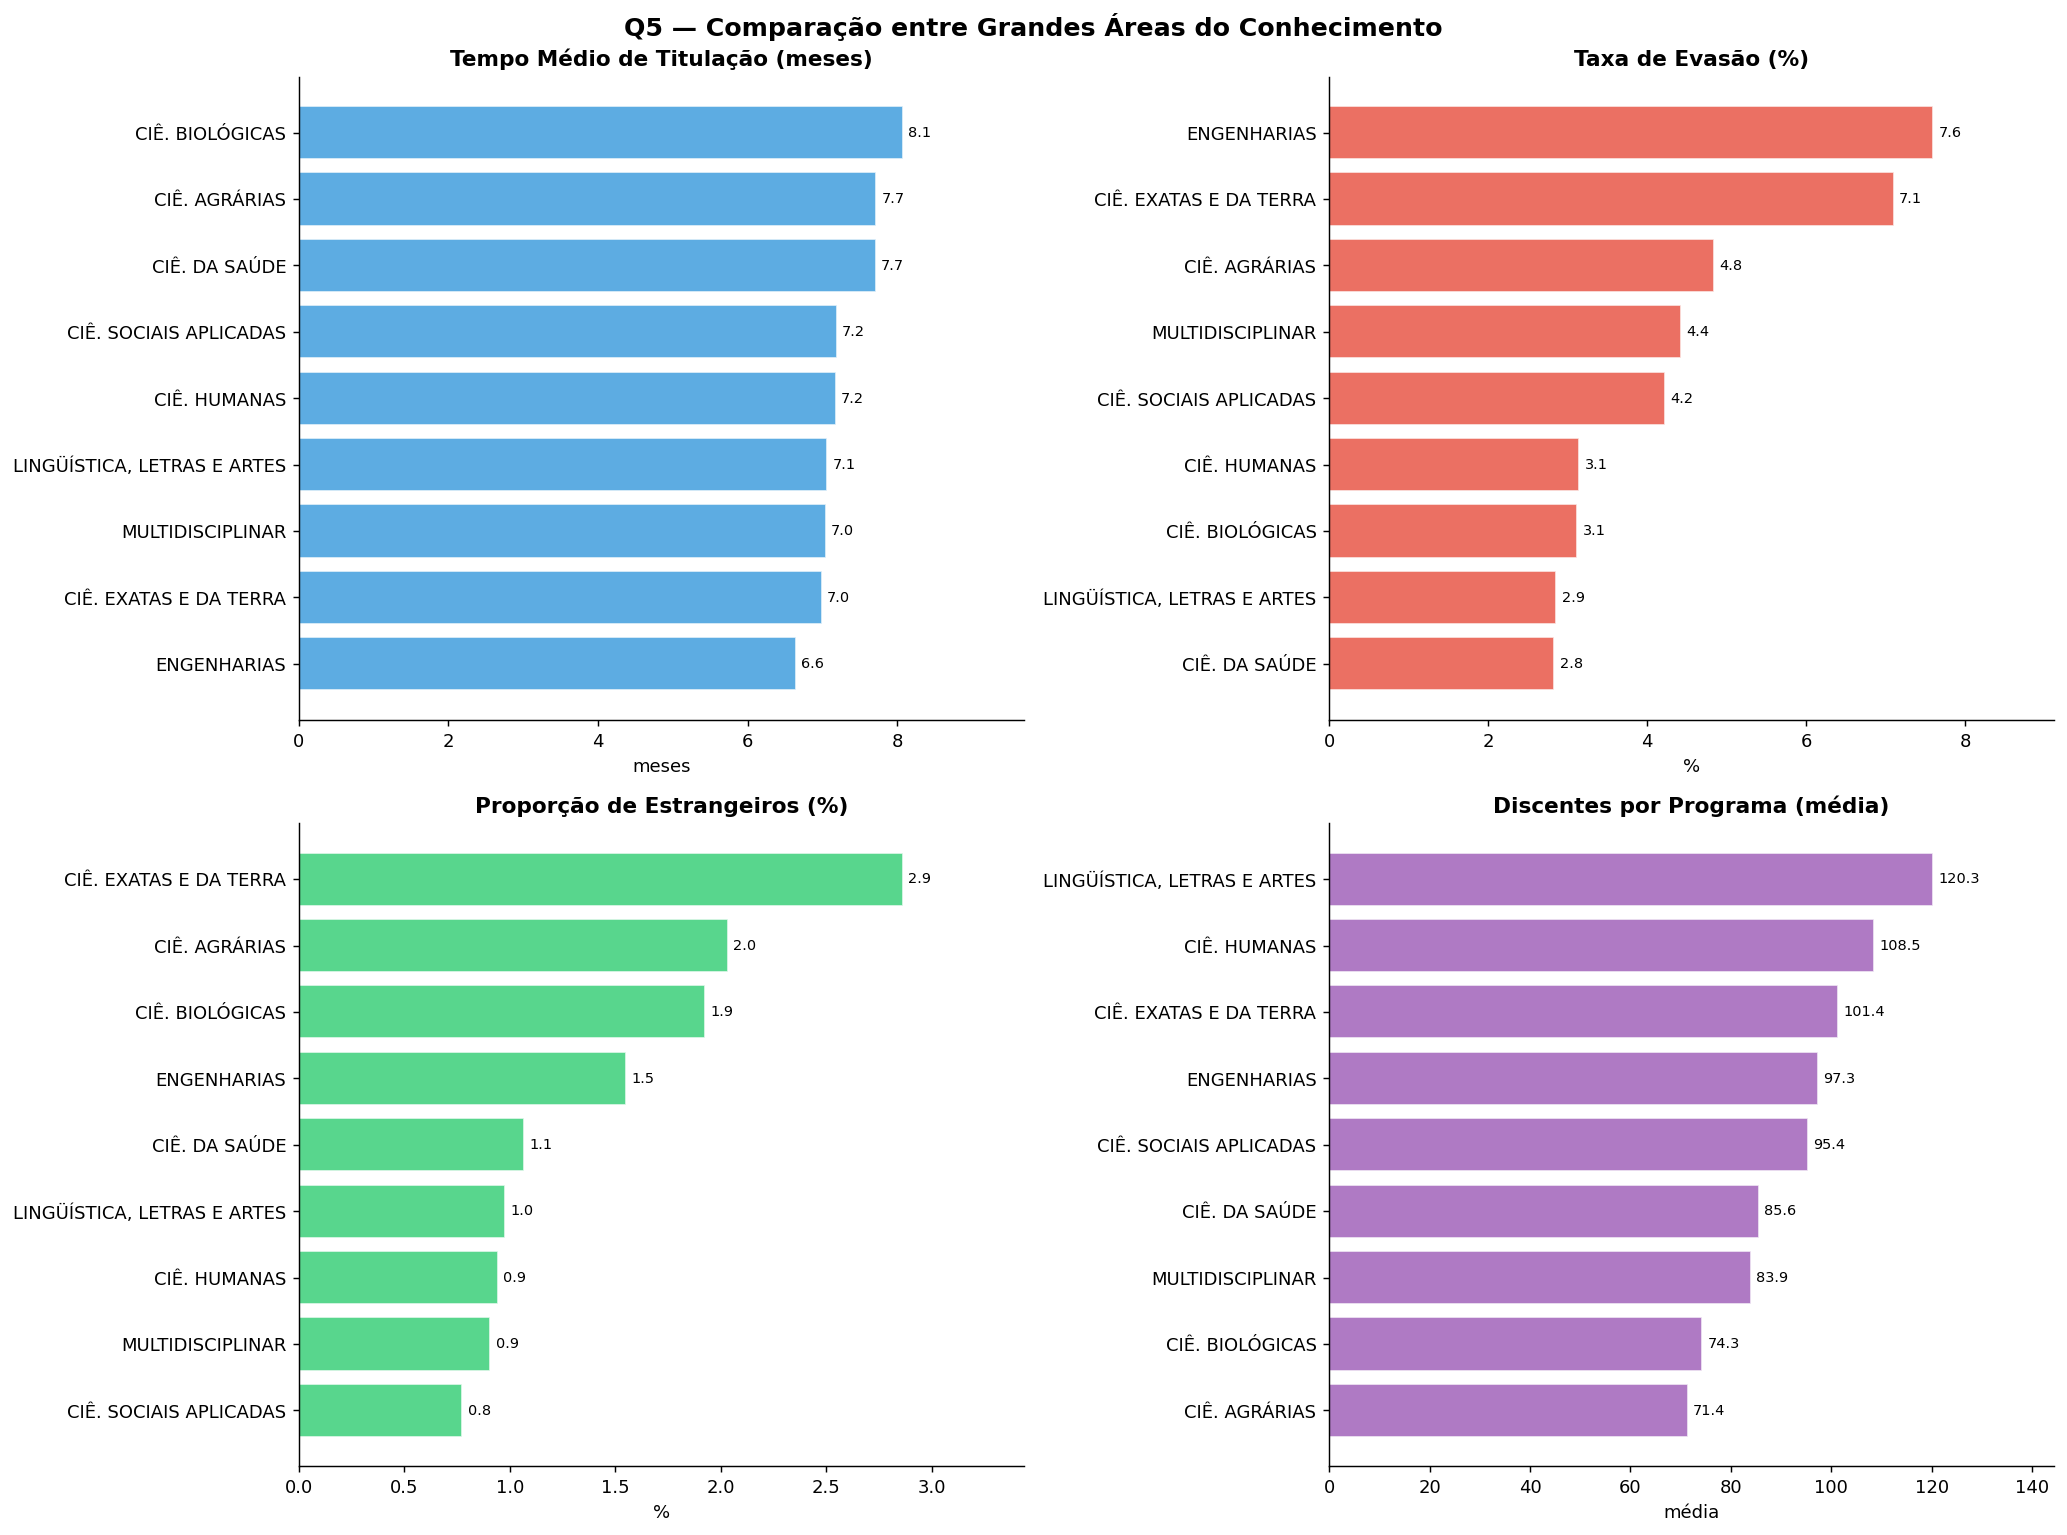

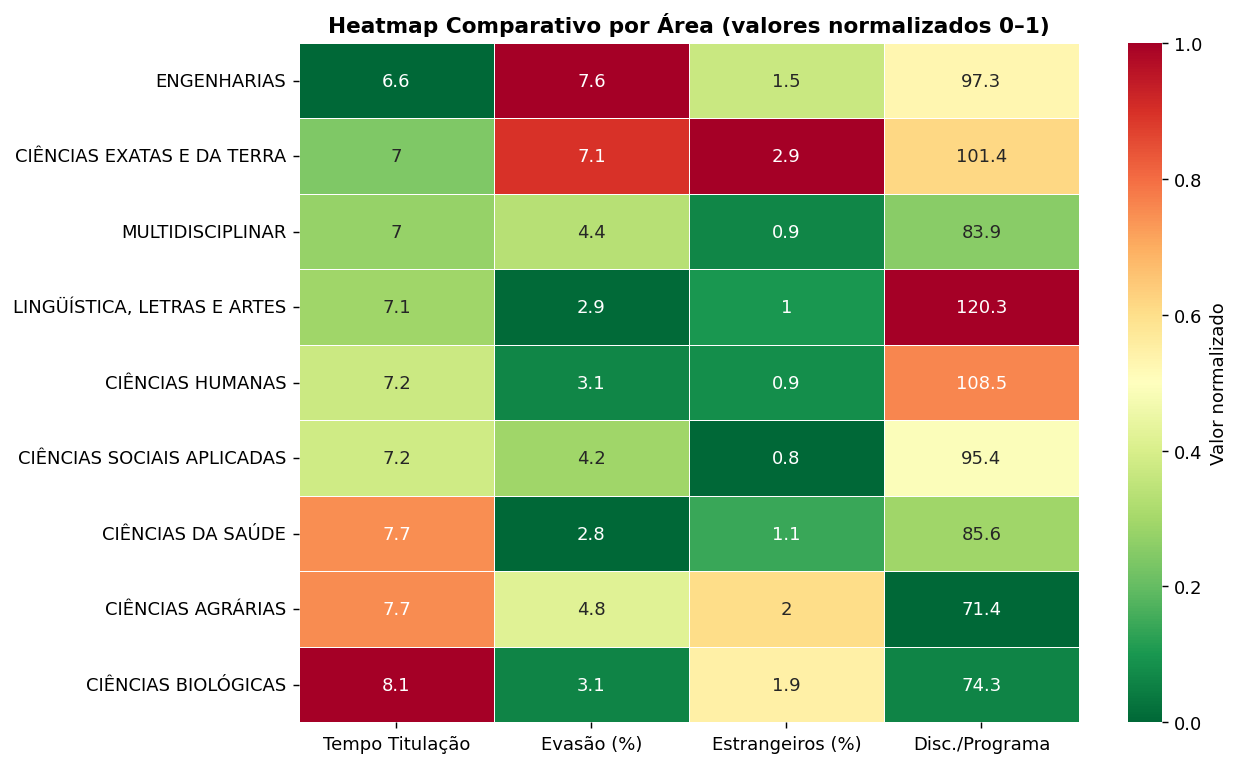


📊 Tabela Completa — Métricas por Grande Área


,Grande Área,Tempo Tit. (meses),Evasão (%),Estrangeiros (%),Disc./Programa,Nº Programas
6,ENGENHARIAS,6.65,7.60,1.55,97.27,469
3,CIÊNCIAS EXATAS E DA TERRA,6.99,7.10,2.86,101.39,363
8,MULTIDISCIPLINAR,7.04,4.42,0.91,83.95,871
7,"LINGÜÍSTICA, LETRAS E ARTES",7.06,2.86,0.98,120.27,243
4,CIÊNCIAS HUMANAS,7.18,3.15,0.94,108.48,711
5,CIÊNCIAS SOCIAIS APLICADAS,7.19,4.23,0.77,95.36,674
2,CIÊNCIAS DA SAÚDE,7.71,2.83,1.07,85.56,754
0,CIÊNCIAS AGRÁRIAS,7.72,4.84,2.03,71.36,448
1,CIÊNCIAS BIOLÓGICAS,8.08,3.12,1.92,74.28,321


In [ ]:

# Agregar por grande área
area_stats = disc.groupby(['NM_GRANDE_AREA_CONHECIMENTO','CD_PROGRAMA_IES','AN_BASE']).agg(
    tempo_med=('QT_MES_TITULACAO', 'mean'),
    taxa_evasao=('IS_EVADIDO', 'mean'),
    prop_estrang=('IS_ESTRANGEIRO', 'mean'),
    n_disc=('ID_PESSOA', 'count')
).reset_index()

area_resumo = area_stats.groupby('NM_GRANDE_AREA_CONHECIMENTO').agg(
    tempo_medio=('tempo_med','mean'),
    taxa_evasao=('taxa_evasao','mean'),
    prop_estrangeiros=('prop_estrang','mean'),
    disc_por_programa=('n_disc','mean'),
    n_programas=('CD_PROGRAMA_IES','nunique')
).reset_index()
area_resumo['taxa_evasao'] *= 100
area_resumo['prop_estrangeiros'] *= 100
area_resumo = area_resumo.sort_values('tempo_medio', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Q5 — Comparação entre Grandes Áreas do Conhecimento',
             fontsize=14, fontweight='bold')

metricas = [
    ('tempo_medio', 'Tempo Médio de Titulação (meses)', '#3498db'),
    ('taxa_evasao', 'Taxa de Evasão (%)', '#e74c3c'),
    ('prop_estrangeiros', 'Proporção de Estrangeiros (%)', '#2ecc71'),
    ('disc_por_programa', 'Discentes por Programa (média)', '#9b59b6'),
]

for ax, (col, label, color) in zip(axes.flat, metricas):
    sub = area_resumo.sort_values(col, ascending=True)
    areas_short = sub['NM_GRANDE_AREA_CONHECIMENTO'].str.replace(
        'CIÊNCIAS','CIÊ.', regex=False).str[:30]
    bars = ax.barh(areas_short, sub[col], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label.split('(')[1].replace(')','') if '(' in label else '')
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
    ax.set_xlim(0, sub[col].max() * 1.2)

plt.tight_layout()
plt.savefig('q5_comparacao_areas.png', bbox_inches='tight')
plt.show()

# Heatmap normalizado
fig2, ax2 = plt.subplots(figsize=(10, 6))
heat_df = area_resumo.set_index('NM_GRANDE_AREA_CONHECIMENTO')[
    ['tempo_medio','taxa_evasao','prop_estrangeiros','disc_por_programa']]
heat_df.columns = ['Tempo Titulação','Evasão (%)','Estrangeiros (%)','Disc./Programa']
heat_norm = (heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())
sns.heatmap(heat_norm, annot=heat_df.round(1), fmt='g', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax2, cbar_kws={'label':'Valor normalizado'})
ax2.set_title('Heatmap Comparativo por Área (valores normalizados 0–1)', fontweight='bold')
ax2.set_ylabel('')
plt.tight_layout()
plt.savefig('q5_heatmap_areas.png', bbox_inches='tight')
plt.show()

print('\n Tabela Completa — Métricas por Grande Área')
display(area_resumo.rename(columns={
    'NM_GRANDE_AREA_CONHECIMENTO':'Grande Área',
    'tempo_medio':'Tempo Tit. (meses)',
    'taxa_evasao':'Evasão (%)',
    'prop_estrangeiros':'Estrangeiros (%)',
    'disc_por_programa':'Disc./Programa',
    'n_programas':'Nº Programas'
}).round(2))


### 🔍 Conclusões Q5
- **Ciências Biológicas e Ciências da Saúde** tendem a ter os maiores tempos de titulação (doutorados longos).
- **Linguística, Letras e Artes** e **Ciências Humanas** apresentam as maiores taxas de evasão relativas.
- A **maior proporção de estudantes estrangeiros** é encontrada em áreas de **Ciências Exatas e da Terra** e **Engenharias**.
- Áreas **Multidisciplinar e Profissionalizantes** concentram maior volume médio de discentes por programa.


---
##  Síntese Geral das Análises

| Questão | Principal Achado |
|---|---|
| **Q1** | ~60–65% dos programas são públicos; Norte e Nordeste têm maior concentração pública |
| **Q2** | Programas com conceito mais alto evitam mais evasão; tempo de titulação cresce com o conceito |
| **Q3** | Profissionais: alunos mais velhos, menor tempo de titulação, maior evasão |
| **Q4** | Crescimento contínuo em todas as regiões; Nordeste em aceleração |
| **Q5** | Grande variação entre áreas em todas as métricas; heatmap revela perfis distintos |

---

